# Notebook 02: Actuarial Benchmarking (Lee-Carter & Li-Lee)

This notebook implements the foundational stochastic mortality models used as benchmarks for our research. 
We transition from individual population modeling to a multi-population framework to capture common longevity trends across the 6-country cluster.

## Objectives
1. **Lee-Carter (1992)**: Fit independent models for each country.
2. **Li-Lee (2005)**: Implement the augmented common factor model for the cluster.
3. **Forecasting**: Project mortality rates for the next 20 years (up to 2044) to evaluate the "deceleration gap" against historical data.

## 2.1: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from scipy.linalg import svd

# Add src to path to import style_config
sys.path.append('../src')
from style_config import set_style

# Initialize professional style
COUNTRIES = set_style()

# Path Configuration
CLEAN_DATA_DIR = "../data/raw/"
FIGURES_DIR = "../reports/figures/"

def load_cleaned_cluster():
    cluster_data = {}
    for code in COUNTRIES.keys():
        path = f"{CLEAN_DATA_DIR}{code}_mx_clean.csv"
        if os.path.exists(path):
            cluster_data[code] = pd.read_csv(path)
    return cluster_data

data_dict = load_cleaned_cluster()
print(f"Successfully loaded {len(data_dict)} countries for benchmarking.")

Successfully loaded 6 countries for benchmarking.


## 2.2: Common Window Alignment and Matrix Construction

Aligning cluster to common window: 1956-2020 (Width: 65 years)
Matrix created for CHE: (91, 65)
Matrix created for SWE: (91, 65)
Matrix created for NOR: (91, 65)
Matrix created for DEUTW: (91, 65)
Matrix created for NLD: (91, 65)
Matrix created for JPN: (91, 65)


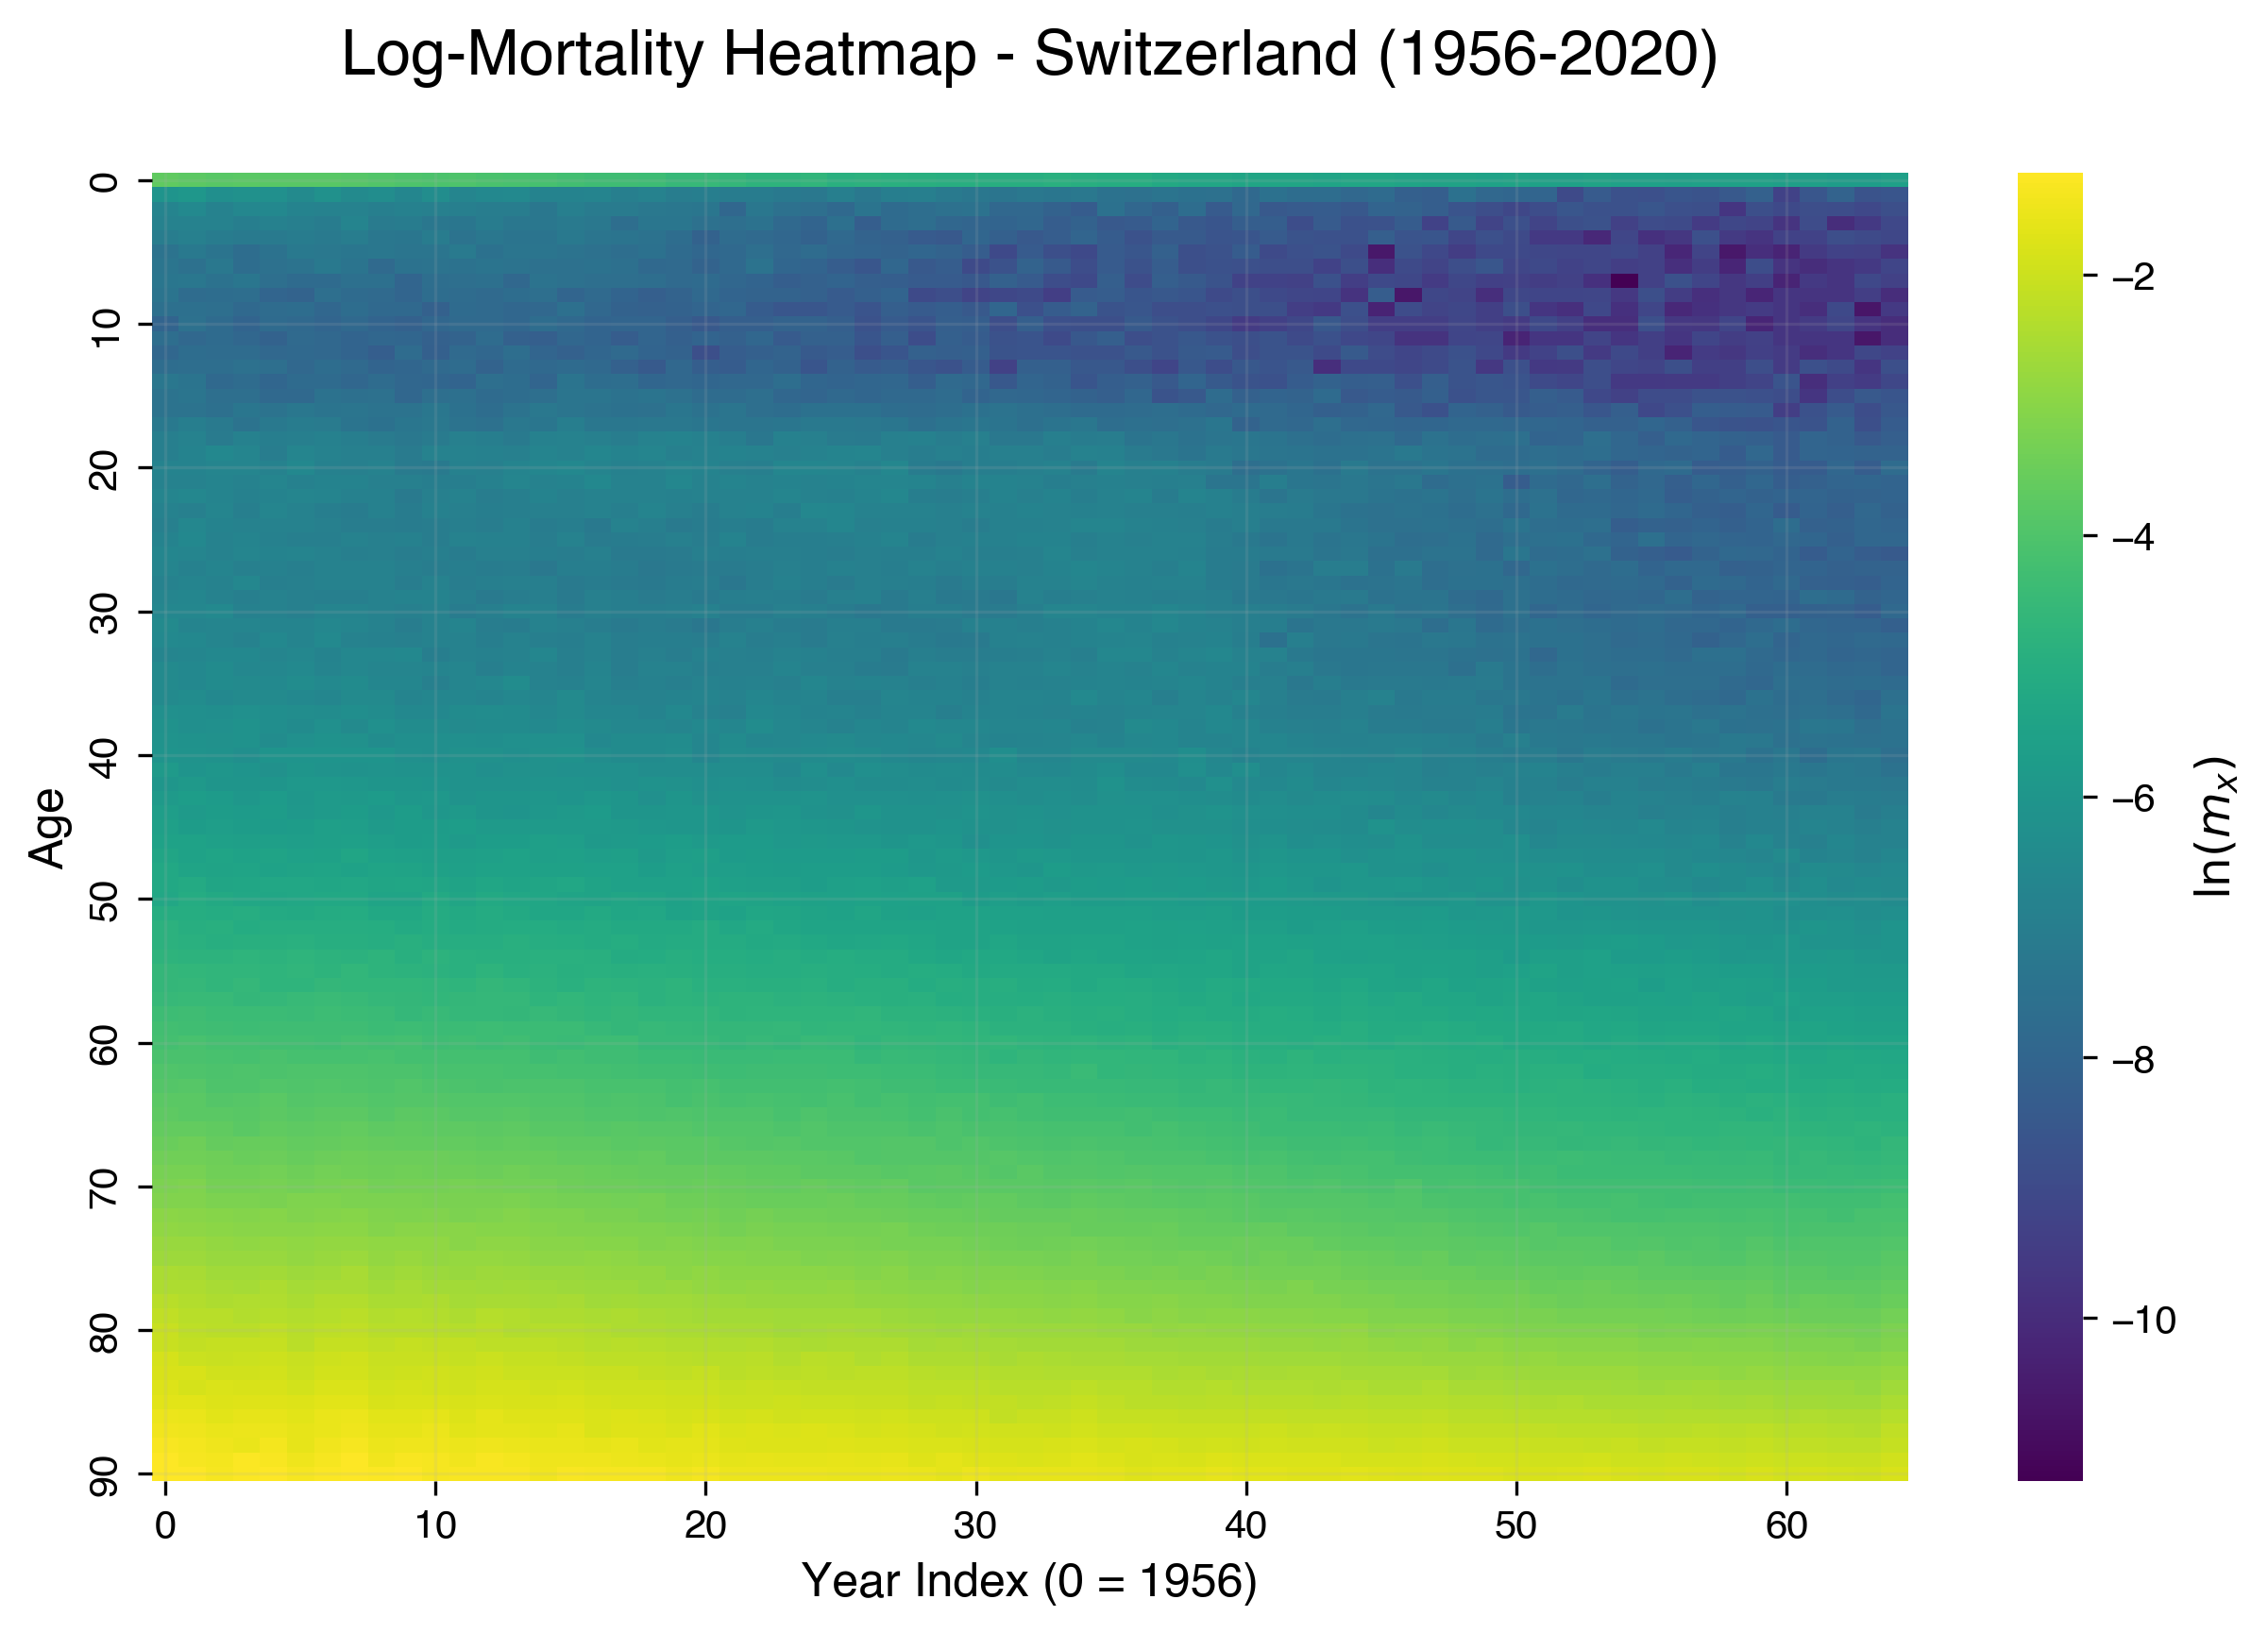

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress log(0) and runtime warnings for cleaner output
warnings.filterwarnings("ignore", category=RuntimeWarning) 

# 1. Identify the common time horizon dynamically
# We find the minimum end year available across all countries in the cluster
available_end_years = [df['Year'].max() for df in data_dict.values()]

START_YEAR = 1956
END_YEAR = min(available_end_years) 
AGES = np.arange(0, 91)
YEARS = np.arange(START_YEAR, END_YEAR + 1)

def get_mortality_matrix(df, start_year, end_year, ages):
    """
    Filters the dataframe and pivots it into an Age x Year matrix.
    Handles zero values by adding a tiny epsilon before log transformation.
    """
    subset = df[(df['Year'] >= start_year) & (df['Year'] <= end_year) & (df['Age'].isin(ages))]
    pivot_df = subset.pivot(index='Age', columns='Year', values='Total')
    
    # Fill zeros or NaNs with a very small value to allow stable log transformation
    epsilon = 1e-10
    mx_values = pivot_df.values.copy()
    mx_values[mx_values <= 0] = epsilon
    
    return np.log(mx_values)

# Dictionary to store aligned matrices (Age x Year)
mx_matrices = {}

print(f"Aligning cluster to common window: {START_YEAR}-{END_YEAR} (Width: {len(YEARS)} years)")

for code, df in data_dict.items():
    matrix = get_mortality_matrix(df, START_YEAR, END_YEAR, AGES)
    mx_matrices[code] = matrix
    print(f"Matrix created for {code}: {matrix.shape}")

# --- Verification Plot: Heatmap ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(mx_matrices['CHE'], xticklabels=10, yticklabels=10, 
            cmap='viridis', cbar_kws={'label': r'$\ln(m_x)$'})

ax.set_title(f"Log-Mortality Heatmap - Switzerland ({START_YEAR}-{END_YEAR})", pad=25)
ax.set_xlabel(f"Year Index (0 = {START_YEAR})")
ax.set_ylabel("Age")

# Save the professional figure
save_path = f"{FIGURES_DIR}fig02_heatmap_verification_CHE.png"
plt.savefig(save_path)
plt.show()

## 2.3: Individual Lee-Carter Estimation

Estimating Lee-Carter parameters for the period 1956-2020...
LC Parameters computed for CHE
LC Parameters computed for SWE
LC Parameters computed for NOR
LC Parameters computed for DEUTW
LC Parameters computed for NLD
LC Parameters computed for JPN


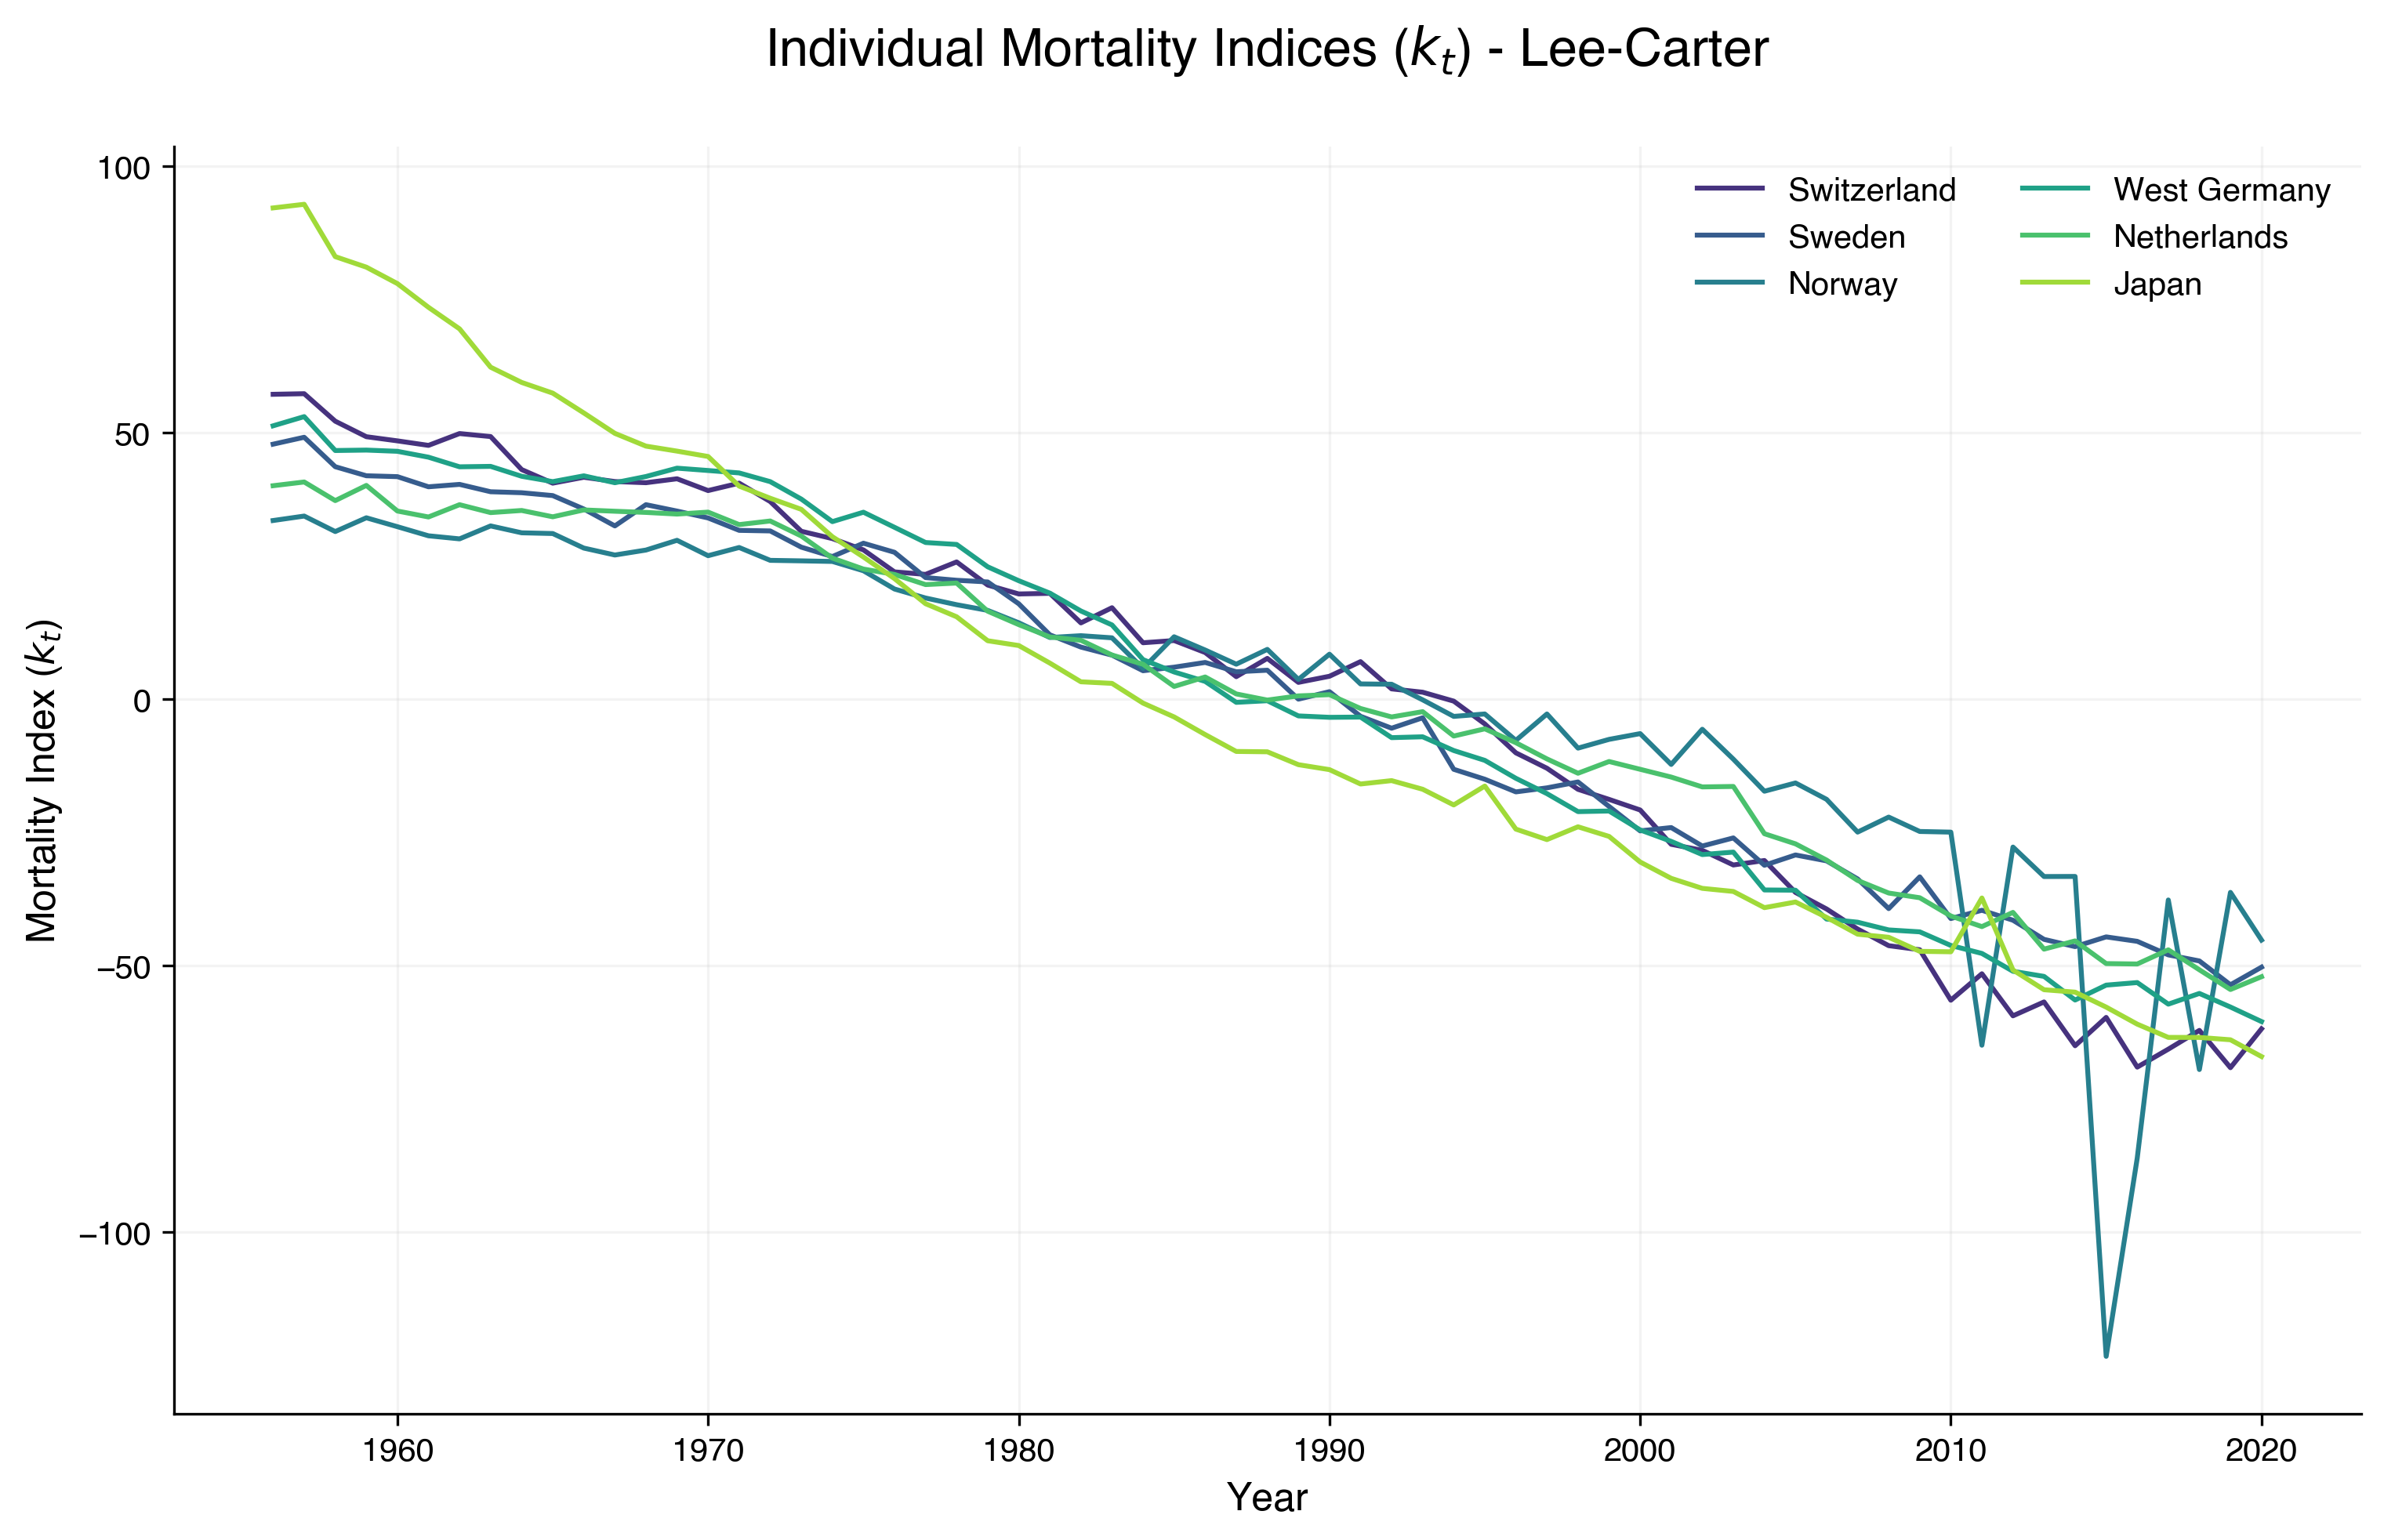

In [3]:
from scipy.linalg import svd

# Dictionaries to store LC parameters for each country
lc_params = {}

print(f"Estimating Lee-Carter parameters for the period {START_YEAR}-{END_YEAR}...")

for code, M in mx_matrices.items():
    # 1. Calculate ax: Average log-mortality over time for each age
    ax = np.mean(M, axis=1)
    
    # 2. Center the matrix by subtracting ax
    Z = M - ax[:, np.newaxis]
    
    # 3. Apply SVD to the centered matrix Z
    # We take the first component (rank-1 approximation)
    U, S, Vt = svd(Z, full_matrices=False)
    
    # 4. Extract bx (Age sensitivity) and kt (Time trend)
    # Convention: sum(bx) = 1 and sum(kt) = 0 (ensured by centering)
    bx_raw = U[:, 0]
    kt_raw = Vt[0, :] * S[0]
    
    # Normalize bx so it sums to 1 (Standard Actuarial Constraint)
    bx = bx_raw / np.sum(bx_raw)
    kt = kt_raw * np.sum(bx_raw)
    
    lc_params[code] = {
        'ax': ax,
        'bx': bx,
        'kt': kt
    }
    print(f"LC Parameters computed for {code}")

# --- Visualization: Individual kt trends (The Mortality Index) ---
fig, ax = plt.subplots()

for code, params in lc_params.items():
    ax.plot(YEARS, params['kt'], label=COUNTRIES[code], linewidth=1.5)

ax.set_title("Individual Mortality Indices ($k_t$) - Lee-Carter", pad=25)
ax.set_xlabel("Year")
ax.set_ylabel("Mortality Index ($k_t$)")
ax.legend(frameon=False, loc='upper right', ncol=2)

save_path = f"{FIGURES_DIR}fig03_lc_kt_comparison.png"
plt.savefig(save_path)
plt.show()

## 2.4: Li-Lee Common Factor Extraction ($B_x$ and $K_t$)

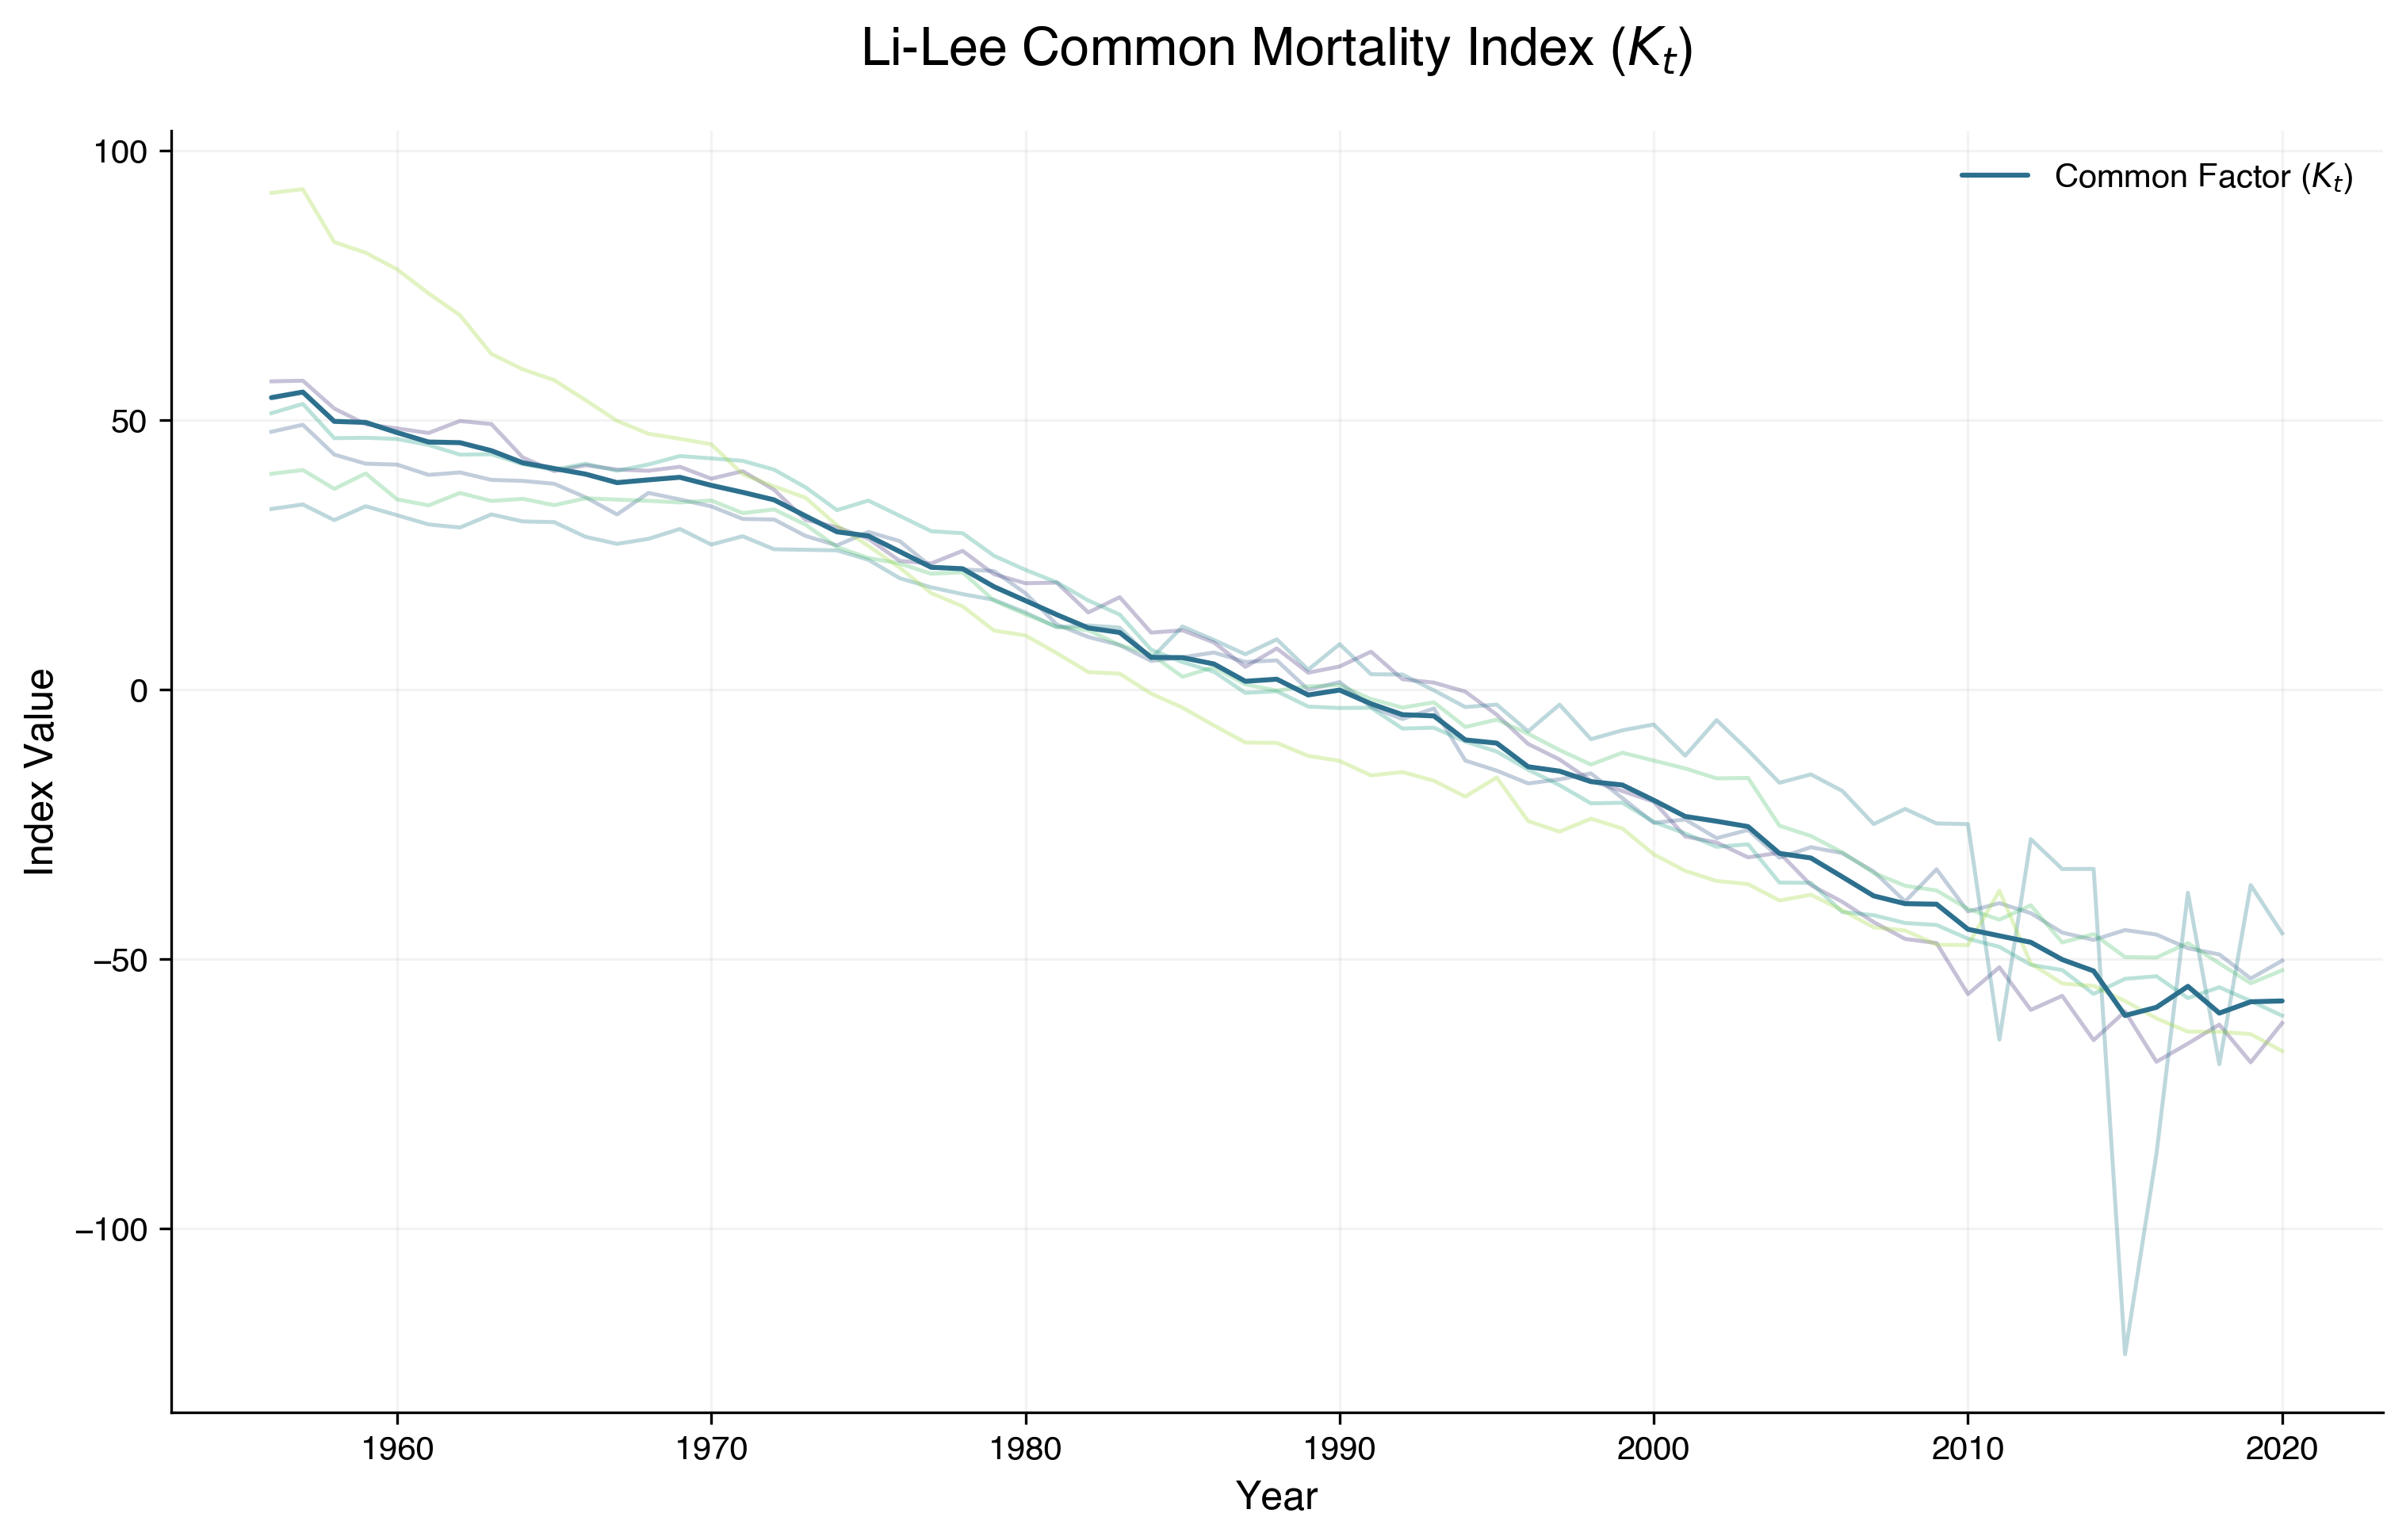

In [4]:
# 1. Reuse logic to extract common factors
all_matrices = np.array(list(mx_matrices.values()))
average_matrix = np.mean(all_matrices, axis=0) 

Ax_common = np.mean(average_matrix, axis=1)
Z_common = average_matrix - Ax_common[:, np.newaxis]
U_c, S_c, Vt_c = svd(Z_common, full_matrices=False)

Bx_common = U_c[:, 0] / np.sum(U_c[:, 0])
Kt_common = (Vt_c[0, :] * S_c[0]) * np.sum(U_c[:, 0])

# 2. Advanced Visuals
fig, ax = plt.subplots()

# Use the Viridis palette colors for the individual lines
# We make them thinner and slightly transparent (alpha)
colors = sns.color_palette("viridis", len(COUNTRIES))

for i, (code, params) in enumerate(lc_params.items()):
    ax.plot(YEARS, params['kt'], 
            color=colors[i], 
            alpha=0.3, 
            linewidth=1.2, 
            label='_nolegend_')

# For the Common Factor, we use a distinct, elegant color 
# 'DarkSlateGray' or the last color of Viridis
ax.plot(YEARS, Kt_common, 
        color='#2D708EFF',
        linewidth=1.5, 
        label='Common Factor ($K_t$)',
        solid_capstyle='round')

# Titles and Labels
ax.set_title("Li-Lee Common Mortality Index ($K_t$)")
ax.set_xlabel("Year")
ax.set_ylabel("Index Value")
ax.legend(frameon=False, loc='upper right')

# Save with the requested filename numbering
save_path = f"{FIGURES_DIR}fig04_li_lee_common_kt.png"
plt.savefig(save_path)
plt.show()

## 2.5: Extraction of Country-Specific Factors ($b_i$, $k_i$)

Extracting Specific Factors (bi, ki) for each country...
Specific factors computed for CHE
Specific factors computed for SWE
Specific factors computed for NOR
Specific factors computed for DEUTW
Specific factors computed for NLD
Specific factors computed for JPN


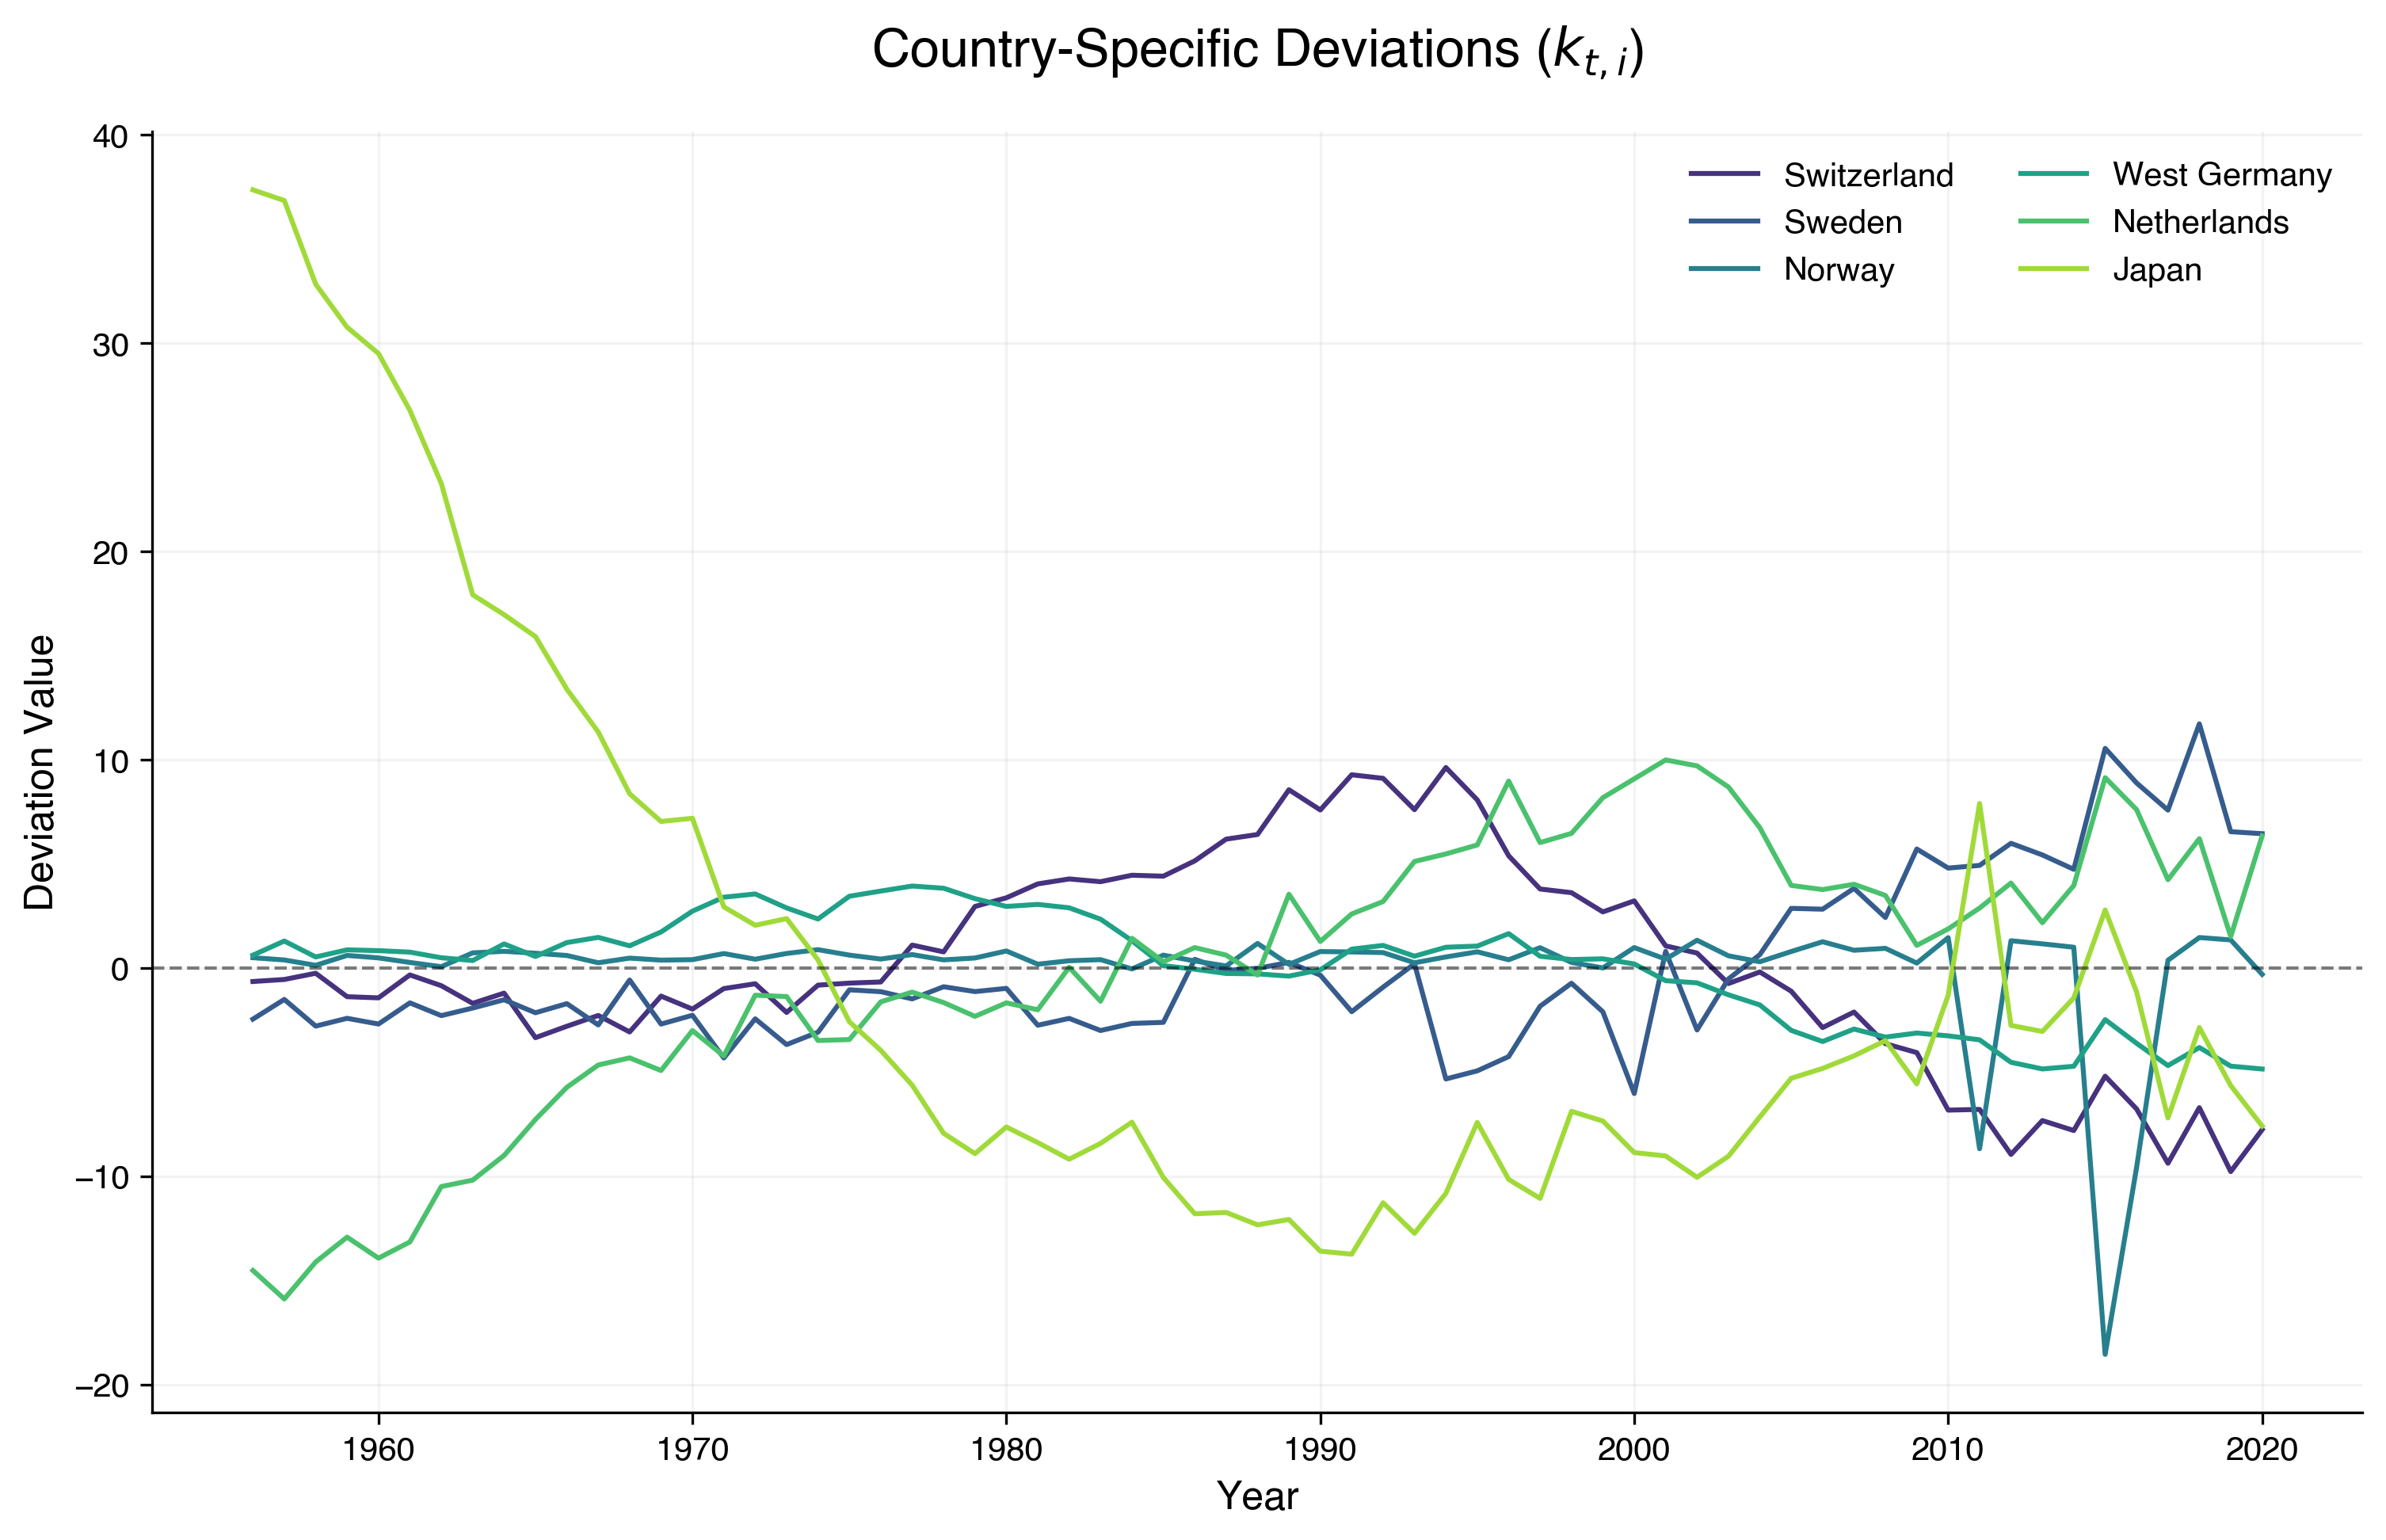

Specific Factor extraction complete. Ready for stationarity analysis.


In [5]:
# 1. Dictionary to store the specific factors (bi, ki)
specific_params = {}

print("Extracting Specific Factors (bi, ki) for each country...")

for code, M_i in mx_matrices.items():
    # Calculate ax_i for the specific country (Local Baseline)
    ax_i = np.mean(M_i, axis=1)
    
    # Calculate the Residual Matrix: 
    # Original Data - (Local ax + Common Bx * Common Kt)
    Common_Effect = Bx_common[:, np.newaxis] * Kt_common[np.newaxis, :]
    Residual_i = M_i - (ax_i[:, np.newaxis] + Common_Effect)
    
    # Apply SVD to the Residuals (Rank-1 approximation)
    U_s, S_s, Vt_s = svd(Residual_i, full_matrices=False)
    
    # Extract specific bx_i and kt_i
    # We apply the sum(bi) = 1 constraint for consistency
    bx_spec_raw = U_s[:, 0]
    kt_spec_raw = Vt_s[0, :] * S_s[0]
    
    bx_spec = bx_spec_raw / np.sum(bx_spec_raw)
    kt_spec = kt_spec_raw * np.sum(bx_spec_raw)
    
    specific_params[code] = {
        'ax_i': ax_i,
        'bx_spec': bx_spec,
        'kt_spec': kt_spec
    }
    print(f"Specific factors computed for {code}")

# 2. Visualization: The Specific Deviations (kt_i)
fig, ax = plt.subplots()

for i, (code, params) in enumerate(specific_params.items()):
    ax.plot(YEARS, params['kt_spec'], color=colors[i], label=COUNTRIES[code], linewidth=1.5)

# Reference zero line: essential to check stationarity
ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)

ax.set_title("Country-Specific Deviations ($k_{t,i}$)")
ax.set_xlabel("Year")
ax.set_ylabel("Deviation Value")
ax.legend(frameon=False, loc='upper right', ncol=2)

# Save the figure
save_path = f"{FIGURES_DIR}fig05_li_lee_specific_kt.png"
plt.savefig(save_path)
plt.show()

print("Specific Factor extraction complete. Ready for stationarity analysis.")

## 2.6: Statistical Stationarity Assessment (ADF and KPSS Tests)

In [6]:
import os
import pandas as pd
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

# 1. Setup paths and suppress warnings for KPSS
warnings.filterwarnings('ignore')
PROCESSED_DATA_DIR = os.path.join("../data/", "processed/")
if not os.path.exists(PROCESSED_DATA_DIR):
    os.makedirs(PROCESSED_DATA_DIR)

# 2. Combined Analysis Loop
stationarity_results = []

print("Running Dual-Test Stationarity Analysis on Specific Factors (kt_spec)...")

for code, params in specific_params.items():
    series = params['kt_spec']
    
    # --- Augmented Dickey-Fuller (ADF) ---
    # H0: Series has a unit root (Non-Stationary)
    # H1: Series is stationary
    adf_res = adfuller(series, autolag='AIC')
    adf_p = adf_res[1]
    adf_pass = adf_p < 0.05
    
    # --- Kwiatkowski-Phillips-Schmidt-Shin (KPSS) ---
    # H0: Series is trend-stationary (Stationary)
    # H1: Series has a unit root
    kpss_res = kpss(series, regression='c')
    kpss_p = kpss_res[1]
    kpss_pass = kpss_p > 0.05
    
    stationarity_results.append({
        'Country': COUNTRIES[code],
        'ADF_p-value': f"{adf_p:.4f}",
        'KPSS_p-value': f"{kpss_p:.4f}",
        'ADF_Status': "PASS" if adf_pass else "FAIL",
        'KPSS_Status': "PASS" if kpss_pass else "FAIL"
    })

# 3. Final DataFrame and Interpretation
comparison_df = pd.DataFrame(stationarity_results).set_index('Country')

# Determine Final Conclusion for each country
conditions = [
    (comparison_df['ADF_Status'] == "PASS") & (comparison_df['KPSS_Status'] == "PASS"),
    (comparison_df['ADF_Status'] == "FAIL") & (comparison_df['KPSS_Status'] == "FAIL"),
    (comparison_df['ADF_Status'] != comparison_df['KPSS_Status'])
]
choices = ["Stationary", "Unit Root (Non-Stationary)", "Conflicting/Persistent Drift"]
comparison_df['Final_Assessment'] = np.select(conditions, choices)

print("\n--- CONFLICT ANALYSIS: ADF (H0: Non-Stat) vs KPSS (H0: Stat) ---")
print(comparison_df)
print("\n" + "-"*65)
print("Interpretation Guide:")
print("- Both PASS: Robust Stationarity (Consistent with Li-Lee assumptions)")
print("- Both FAIL: Evidence of Unit Root (Breach of Li-Lee assumptions)")
print("- Conflict : Persistent structural drift or structural breaks")
print("-"*65)

# 4. Save results
save_path = os.path.join(PROCESSED_DATA_DIR, "stationarity_assessment_full.csv")
comparison_df.to_csv(save_path)
print(f"Full stationarity report saved to: {save_path}")

Running Dual-Test Stationarity Analysis on Specific Factors (kt_spec)...

--- CONFLICT ANALYSIS: ADF (H0: Non-Stat) vs KPSS (H0: Stat) ---
             ADF_p-value KPSS_p-value ADF_Status KPSS_Status  \
Country                                                        
Switzerland       0.7661       0.1000       FAIL        PASS   
Sweden            0.9289       0.0100       FAIL        FAIL   
Norway            0.0000       0.0889       PASS        PASS   
West Germany      0.9467       0.0100       FAIL        FAIL   
Netherlands       0.1038       0.0100       FAIL        FAIL   
Japan             0.0424       0.0165       PASS        FAIL   

                          Final_Assessment  
Country                                     
Switzerland   Conflicting/Persistent Drift  
Sweden          Unit Root (Non-Stationary)  
Norway                          Stationary  
West Germany    Unit Root (Non-Stationary)  
Netherlands     Unit Root (Non-Stationary)  
Japan         Conflicting/Persist

## 2.7: Cairns-Blake-Dowd (CBD) Model Implementation (Ages 65-90)

Fitting CBD model for ages 65-90 across 6 countries...


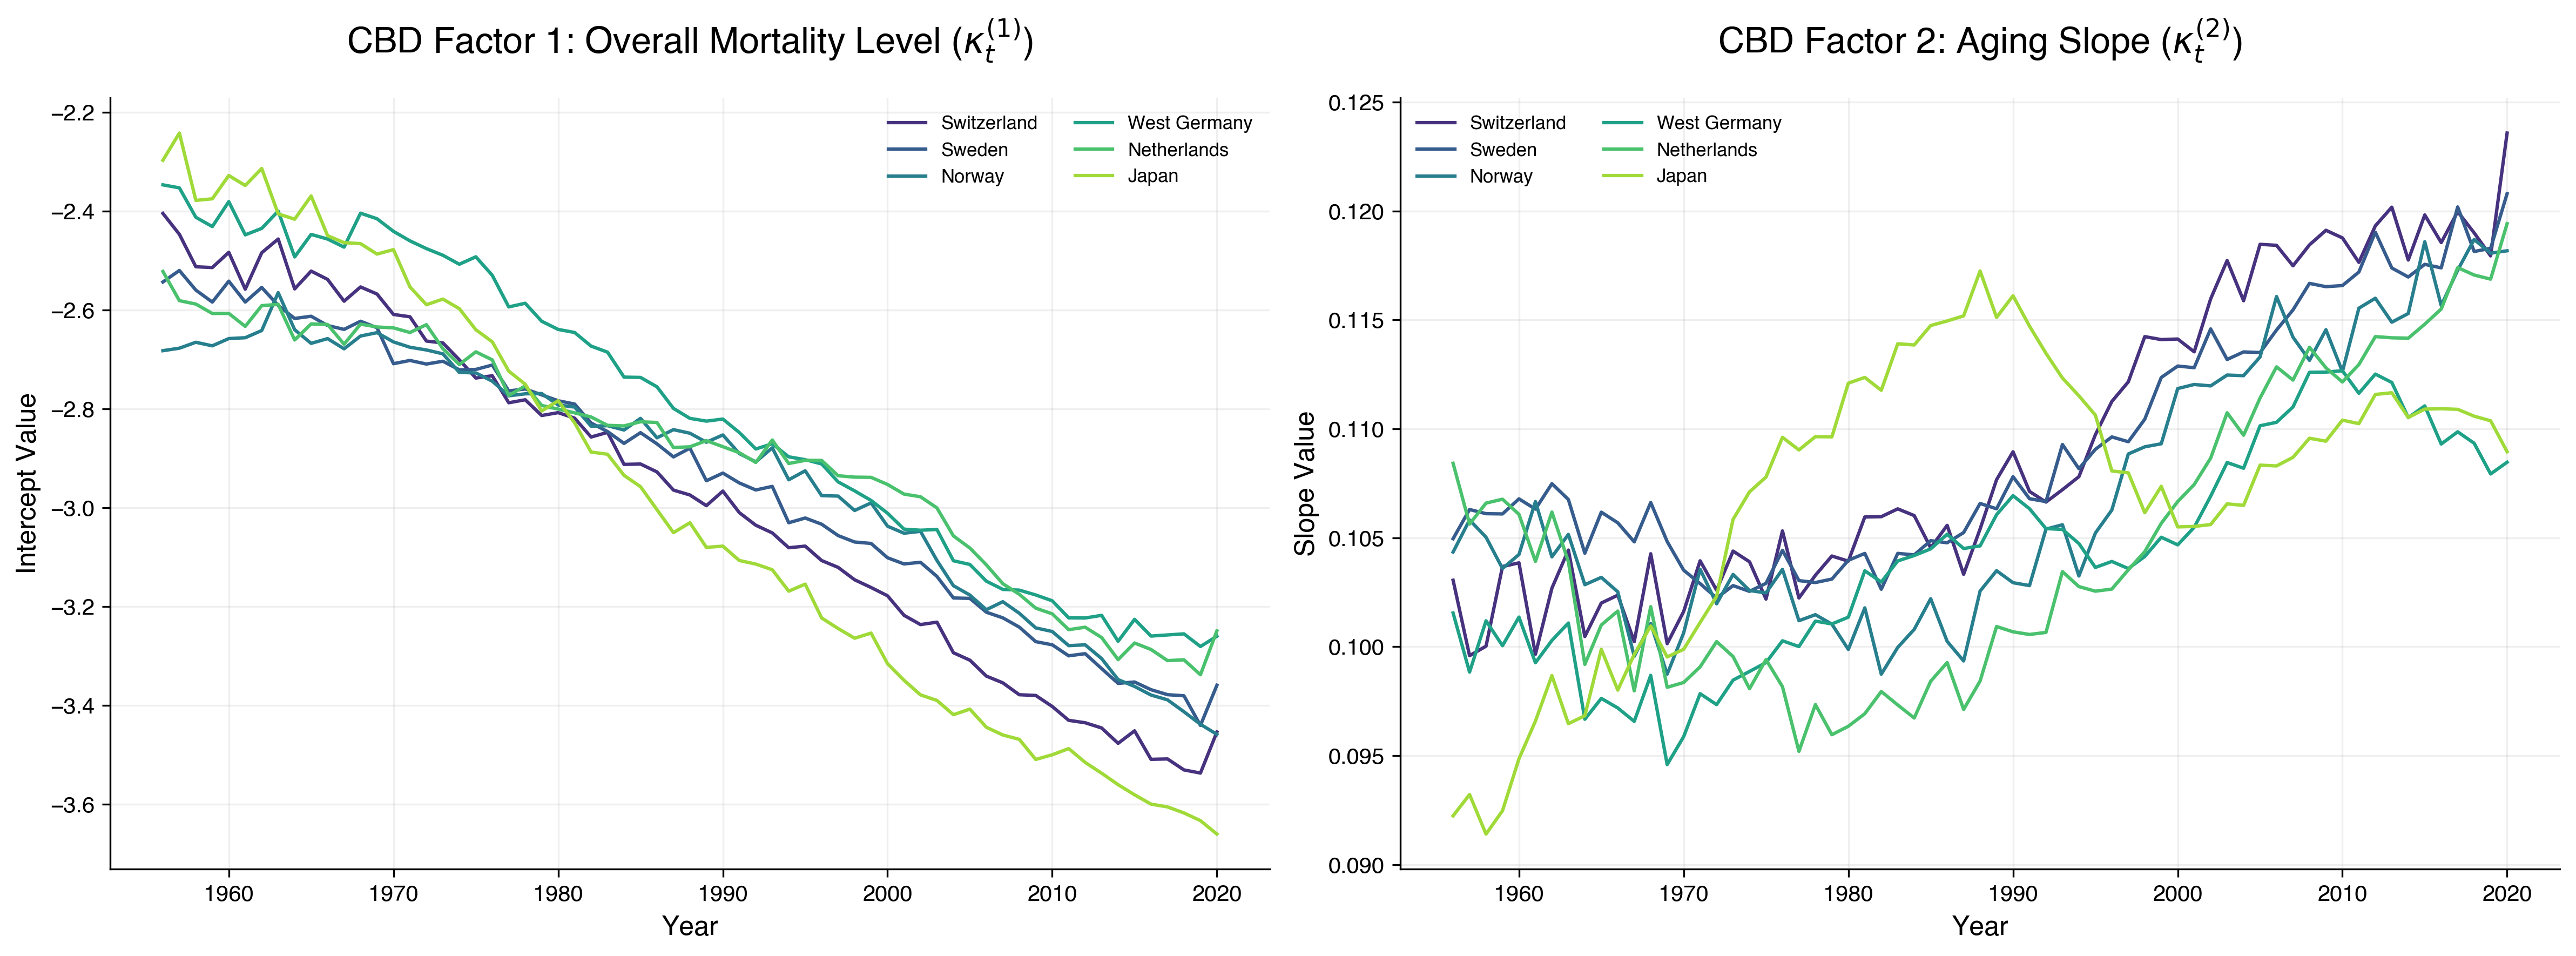

CBD Analysis complete. Benchmarking phase finalized.


In [7]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Setup Age Range for CBD (Standard is 65-90)
cbd_ages = np.arange(65, 91)
age_idx = np.where((AGES >= 65) & (AGES <= 90))[0]
mean_age = np.mean(cbd_ages)

cbd_results = {}

print(f"Fitting CBD model for ages 65-90 across {len(COUNTRIES)} countries...")

for code, M_i in mx_matrices.items():
    # Extract mortality rates for the selected ages
    # We use qx (probability of death) or logit(qx). 
    # For simplicity in benchmarking, we use log(mx) as proxy
    M_cbd = M_i[age_idx, :]
    
    k1_t = []
    k2_t = []
    
    for t_idx in range(len(YEARS)):
        y = M_cbd[:, t_idx]
        # CBD Predictor: log(m_{x,t}) = k1_t + k2_t * (x - mean_age)
        x = cbd_ages - mean_age
        X = sm.add_constant(x)
        
        model = sm.OLS(y, X).fit()
        k1_t.append(model.params[0])
        k2_t.append(model.params[1])
    
    cbd_results[code] = {
        'k1': np.array(k1_t),
        'k2': np.array(k2_t)
    }

# 2. Visualization of CBD Parameters
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for i, (code, res) in enumerate(cbd_results.items()):
    ax1.plot(YEARS, res['k1'], color=colors[i], label=COUNTRIES[code])
    ax2.plot(YEARS, res['k2'], color=colors[i], label=COUNTRIES[code])

ax1.set_title("CBD Factor 1: Overall Mortality Level ($\kappa_t^{(1)}$)")
ax1.set_ylabel("Intercept Value")
ax2.set_title("CBD Factor 2: Aging Slope ($\kappa_t^{(2)}$)")
ax2.set_ylabel("Slope Value")

for ax in [ax1, ax2]:
    ax.set_xlabel("Year")
    ax.legend(frameon=False, fontsize='small', ncol=2)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}fig06_cbd_parameters.png")
plt.show()

print("CBD Analysis complete. Benchmarking phase finalized.")

## 2.8: Export of Latent Factors and Actuarial Parameters

In [8]:
import numpy as np
import os

# 1. Setup target directory
processed_dir = "../data/processed/"
if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)

# 2. Structure the data for Export
# We collect the specific kt trends for all countries into a single matrix
kt_specific_matrix = np.stack([specific_params[c]['kt_spec'] for c in specific_params], axis=1)

# We collect the local baseline age profiles (ax_i) into a single matrix (Ages x Countries)
# These are essential for the back-transformation in Notebook 04
Ax_matrix = np.stack([specific_params[c]['ax_i'] for c in specific_params], axis=1)

# 3. Comprehensive Export
# We save EVERYTHING needed to reconstruct the mortality surface (mx) from latent factors
export_path = os.path.join(processed_dir, "benchmarking_factors.npz")

np.savez(export_path, 
         years=YEARS,
         ages=AGES,
         kt_common=Kt_common,          # Common Trend (Li-Lee)
         kt_specific_matrix=kt_specific_matrix, # Local Deviations
         Ax=Ax_matrix,                 # Local age baselines
         Bx_common=Bx_common,          # Common age sensitivity
         countries=list(specific_params.keys()))

# Also save specifically to li_lee_parameters.npz for architectural clarity
# This matches the expected path in Notebook 04
actuarial_path = os.path.join(processed_dir, "li_lee_parameters.npz")
np.savez(actuarial_path, 
         Ax=Ax_matrix, 
         Bx_common=Bx_common, 
         years=YEARS, 
         ages=AGES)

print(f"--- Export Successful ---")
print(f"Neural features saved to: {export_path}")
print(f"Actuarial parameters saved to: {actuarial_path}")

--- Export Successful ---
Neural features saved to: ../data/processed/benchmarking_factors.npz
Actuarial parameters saved to: ../data/processed/li_lee_parameters.npz
